<a href="https://colab.research.google.com/github/rakshitha-dev9/AIML/blob/main/AIML_Module_01_Lab_01_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extracting features from data

Module 1, Lab 1<br>



In [1]:
! pip install wikipedia

import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
import plotly.express as px
import pandas as pd

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=f45d26a550987b2d808ac6b4206492d2a4d50a0a393ec988dbfc17909eb4add1
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


# Part 1: Features of text
How do we apply machine learning on text? We can't directly use the text as input to our algorithms. We need to convert them to features. In this notebook, we will explore a simple way of converting text to features.

Let us download a few documents off Wikipedia.

In [3]:
topic1 = 'Giraffe'
topic2 = 'Elephant'

wikipedia.set_lang('en')

eng1 = wikipedia.page(topic1).content
eng2 = wikipedia.page(topic2).content

wikipedia.set_lang('fr')

wikipedia.set_lang('fr')
fr1 = wikipedia.page('Girafe').content
fr2 = wikipedia.page('Éléphant').content

This is what the text looks like:

In [4]:
fr2

'Les éléphants sont des mammifères proboscidiens de la famille des Éléphantidés. \nIls correspondent aujourd\'hui à trois espèces réparties en deux genres distincts. L\'éléphant de savane d\'Afrique et l\'éléphant de forêt d\'Afrique, autrefois regroupés sous la même espèce d\'« éléphant d\'Afrique », appartiennent au genre Loxodonta, tandis que l\'éléphant d\'Asie, anciennement appelé « éléphant indien », appartient au genre Elephas. Ils se différencient par certaines caractéristiques anatomiques, les éléphants d\'Asie étant en général plus petits avec des oreilles plus petites, ou encore une différence du bout de la trompe. Ces espèces survivantes font localement l\'objet de programmes ou de projets de réintroduction et de protection.\nLe mot français « éléphant » vient du mot latin elephantus qui tire son origine du grec ἐλέφας / eléphas, « ivoire » ou « éléphant ».\nL\'éléphant apparaît dans de nombreuses cultures. Il est symbole de sagesse en Asie et est  connu pour sa mémoire et 

We need to clean this up a bit. Let us remove all the special characters and keep only 26 letters and space. Note that this will remove accented characters in French also. We are also removing all the numbers and spaces. So this is not an ideal solution.

In [5]:
def cleanup(text):
  text = text.lower()  # make it lowercase
  text = re.sub('[^a-z]+', '', text) # only keep characters
  return text

In [6]:
eng1 = cleanup(eng1)
eng2 = cleanup(eng2)
fr1 = cleanup(fr1)
fr2 = cleanup(fr2)

In [7]:
print(eng1)

...


Now let us calculate the frequency of the character n-grams. N-grams are groups of characters of size n. A unigram is a single character and a bigram is a group of two characters and so on.

Let us count the frequency of each character in a text and plot it in a histogram.

In [8]:
# convert a tuple of characters to a string
def tuple2string(tup):
  st = ''
  for ii in tup:
    st = st + ii
  return st

# convert a tuple of tuples to a list of strings
def key2string(keys):
  return [tuple2string(i) for i in keys]

# plot the histogram
def plothistogram(ngram):
  keys = key2string(ngram.keys())
  values = list(ngram.values())

  # sort the keys in alphabetic order
  combined = zip(keys, values)
  zipped_sorted = sorted(combined, key=lambda x: x[0])
  keys, values = map(list, zip(*zipped_sorted))
  plt.bar(keys, values)

Let us compare the histograms of English pages and French pages. Can you spot a difference?

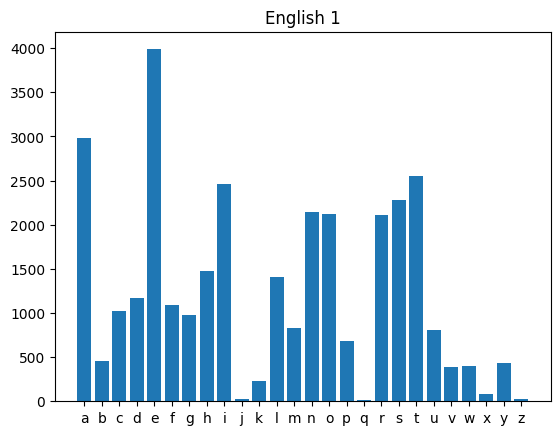

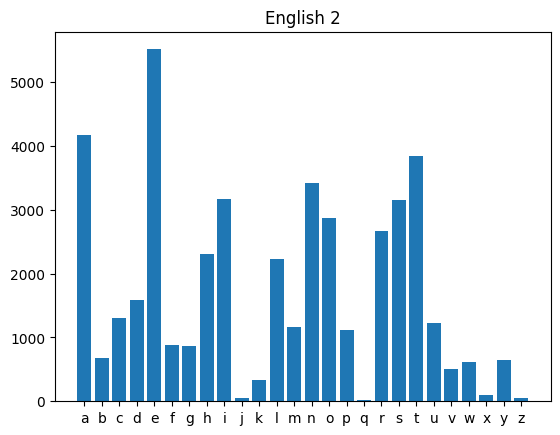

In [9]:
unigram_eng1 = Counter(ngrams(eng1,1))
plothistogram(unigram_eng1)
plt.title('English 1')
plt.show()
unigram_eng2 = Counter(ngrams(eng2,1))
plothistogram(unigram_eng2)
plt.title('English 2')
plt.show()

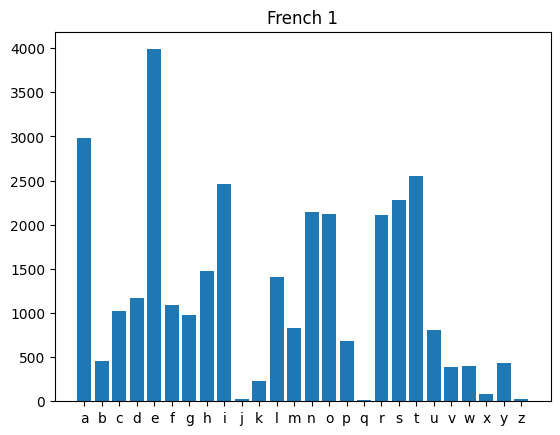

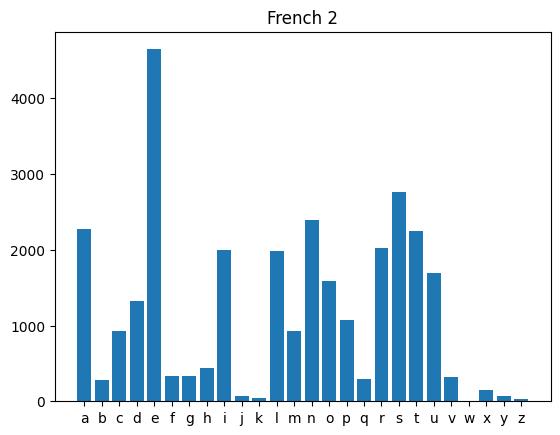

In [10]:
unigram_fr1 = Counter(ngrams(fr1,1))
plothistogram(unigram_eng1)
plt.title('French 1')
plt.show()
unigram_fr2 = Counter(ngrams(fr2,1))
plothistogram(unigram_fr2)
plt.title('French 2')
plt.show()

We can see that the unigrams for French and English are very similar. So this is not a good feature if we want to distinguish between English and French. Let us look at bigrams.

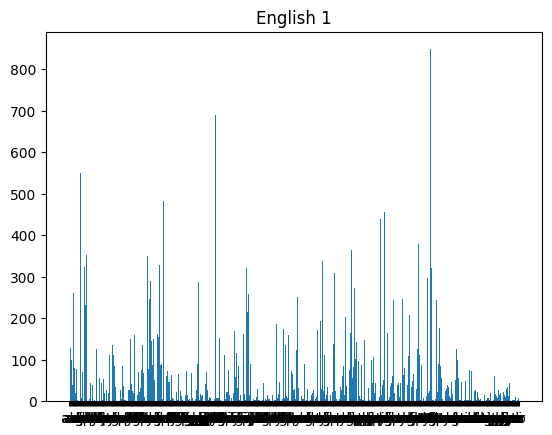

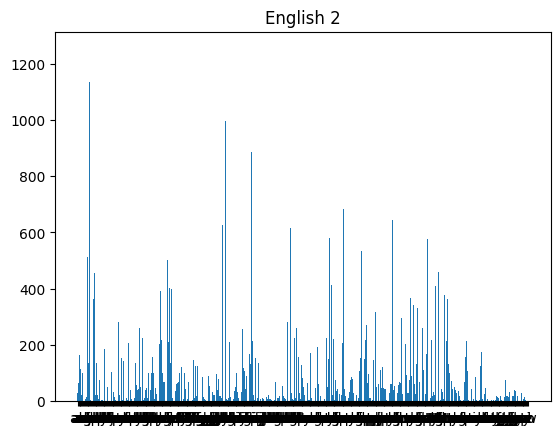

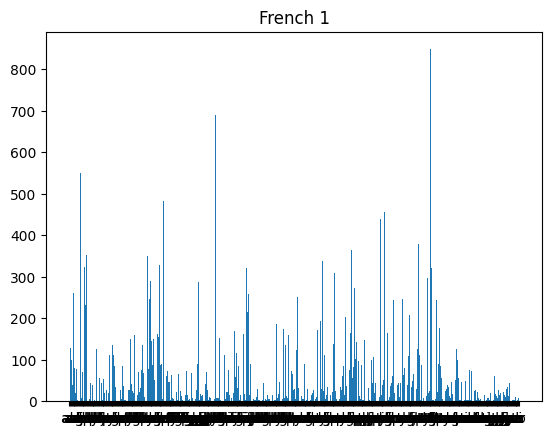

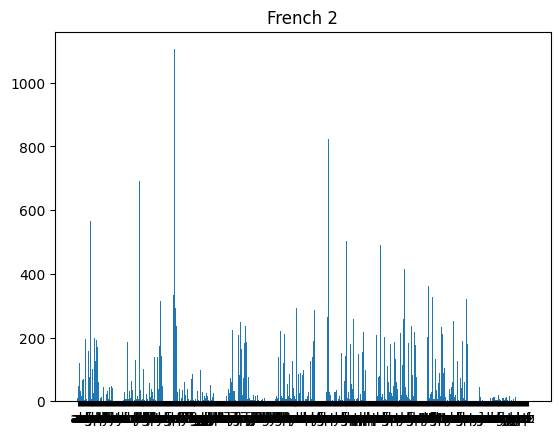

In [11]:
bigram_eng1 = Counter(ngrams(eng1,2)) # bigrams
plothistogram(bigram_eng1)
plt.title('English 1')
plt.show()

bigram_eng2 = Counter(ngrams(eng2,2))
plothistogram(bigram_eng2)
plt.title('English 2')
plt.show()

bigram_fr1 = Counter(ngrams(fr1,2))
plothistogram(bigram_eng1)
plt.title('French 1')
plt.show()

bigram_fr2 = Counter(ngrams(fr2,2))
plothistogram(bigram_fr2)
plt.title('French 2')
plt.show()

Another way to visualize bigrams is to use a 2-dimensional graph.

In [12]:
def plotbihistogram(ngram):
  freq = np.zeros((26,26))
  for ii in range(26):
    for jj in range(26):
      freq[ii,jj] = ngram[(chr(ord('a')+ii), chr(ord('a')+jj))]
  plt.imshow(freq, cmap = 'jet')
  return freq

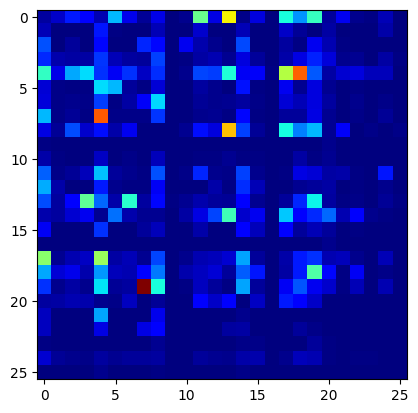

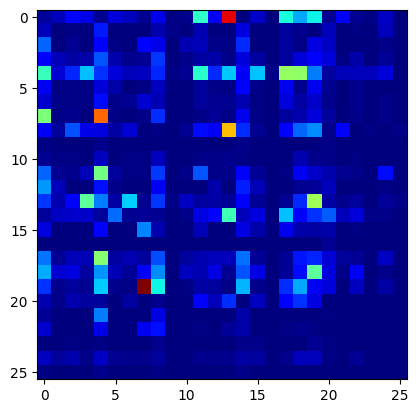

In [13]:
bieng1 = plotbihistogram(bigram_eng1)
plt.show()
bieng2 = plotbihistogram(bigram_eng2)

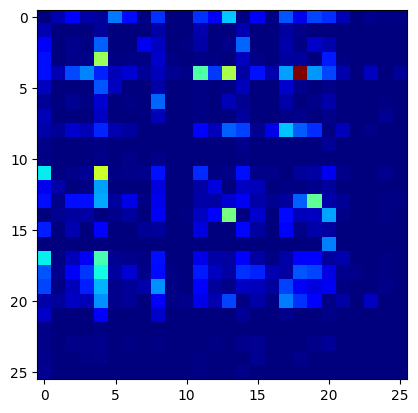

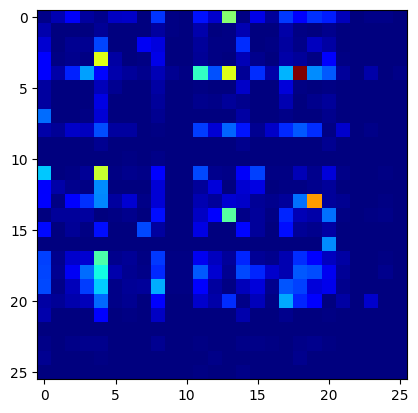

In [14]:
bifr1 = plotbihistogram(bigram_fr1)
plt.show()
bifr2 = plotbihistogram(bigram_fr2)

Let us look at the top 10 ngrams for each text.

In [15]:
from IPython.core.debugger import set_trace

def ind2tup(ind):
  ind = int(ind)
  i = int(ind/26)
  j = int(ind%26)
  return (chr(ord('a')+i), chr(ord('a')+j))

def ShowTopN(bifreq, n=10):
  f = bifreq.flatten()
  arg = np.argsort(-f)
  for ii in range(n):
    print(f'{ind2tup(arg[ii])} : {f[arg[ii]]}')

In [16]:
print('\nEnglish 1:')
ShowTopN(bieng1)
print('\nEnglish 2:')
ShowTopN(bieng2)
print('\nFrench 1:')
ShowTopN(bifr1)
print('\nFrench 2:')
ShowTopN(bifr2)


English 1:
('t', 'h') : 848.0
('h', 'e') : 690.0
('e', 's') : 683.0
('i', 'n') : 598.0
('a', 'n') : 550.0
('e', 'r') : 482.0
('r', 'e') : 455.0
('r', 'a') : 438.0
('a', 'l') : 407.0
('n', 'd') : 397.0

English 2:
('t', 'h') : 1251.0
('a', 'n') : 1134.0
('h', 'e') : 997.0
('i', 'n') : 885.0
('n', 't') : 682.0
('e', 'r') : 662.0
('e', 's') : 656.0
('r', 'e') : 644.0
('h', 'a') : 628.0
('l', 'e') : 615.0

French 1:
('e', 's') : 796.0
('l', 'e') : 478.0
('e', 'n') : 444.0
('d', 'e') : 430.0
('o', 'n') : 392.0
('n', 't') : 372.0
('e', 'l') : 355.0
('r', 'e') : 346.0
('s', 'e') : 298.0
('r', 'a') : 287.0

French 2:
('e', 's') : 1105.0
('n', 't') : 823.0
('d', 'e') : 690.0
('e', 'n') : 686.0
('l', 'e') : 652.0
('a', 'n') : 566.0
('o', 'n') : 504.0
('r', 'e') : 492.0
('e', 'l') : 456.0
('s', 'e') : 414.0


We observe that the bigrams are similar across different topics but different across languages. Thus, the bigram frequency is a good feature for distinguishing languages, but not for distinguishing topics.

Thus, we were able to convert a many-dimensional input (the text) to 26 dimesions (unigrams) or 26*26 dimensions (bigrams).


A few ways to explore:
1. Try with different languages.
2. The topics we used are quite similar, wikipedia articles of 'elephant' and 'giraffe'. What happens if we use very different topics? What if we use text from another source than Wikipedia?
3. How can we use and visualize trigrams and higher n-grams?

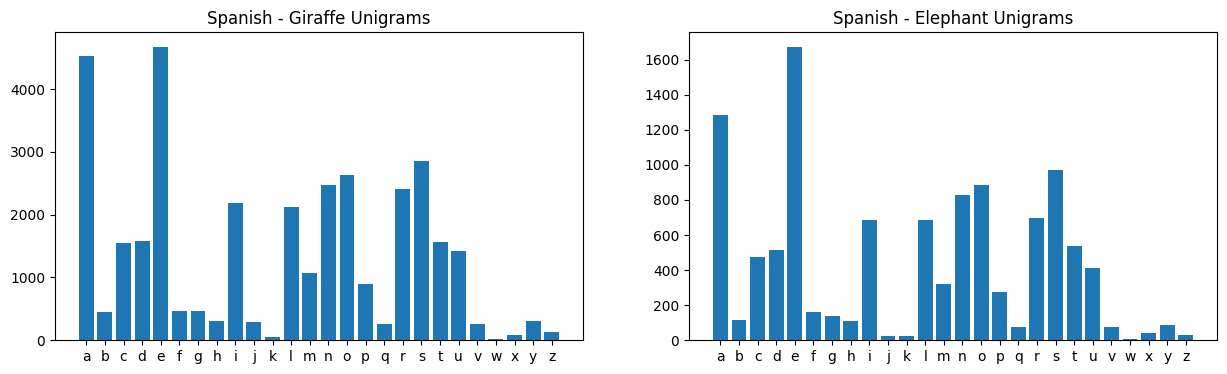

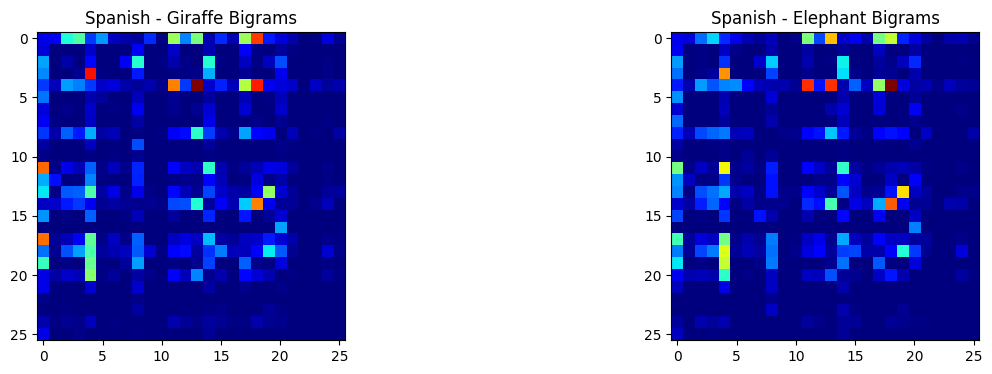

In [33]:
# Exploration Q1: Trying Spanish language
wikipedia.set_lang('es')
es1 = wikipedia.page('Jirafa', auto_suggest=False).content   # Giraffe in Spanish
es2 = wikipedia.page('Elefante', auto_suggest=False).content # Elephant in Spanish

es1_clean = cleanup(es1)
es2_clean = cleanup(es2)

es1_uni = Counter(ngrams(es1_clean, 1))
es2_uni = Counter(ngrams(es2_clean, 1))

es1_bi = Counter(ngrams(es1_clean, 2))
es2_bi = Counter(ngrams(es2_clean, 2))

plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
plothistogram(es1_uni)
plt.title('Spanish - Giraffe Unigrams')

plt.subplot(1,2,2)
plothistogram(es2_uni)
plt.title('Spanish - Elephant Unigrams')
plt.show()

plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
plotbihistogram(es1_bi)
plt.title('Spanish - Giraffe Bigrams')

plt.subplot(1,2,2)
plotbihistogram(es2_bi)
plt.title('Spanish - Elephant Bigrams')
plt.show()

# Observation: Spanish bigrams will look different from English and French,
# confirming bigrams are language-specific and useful for language detection

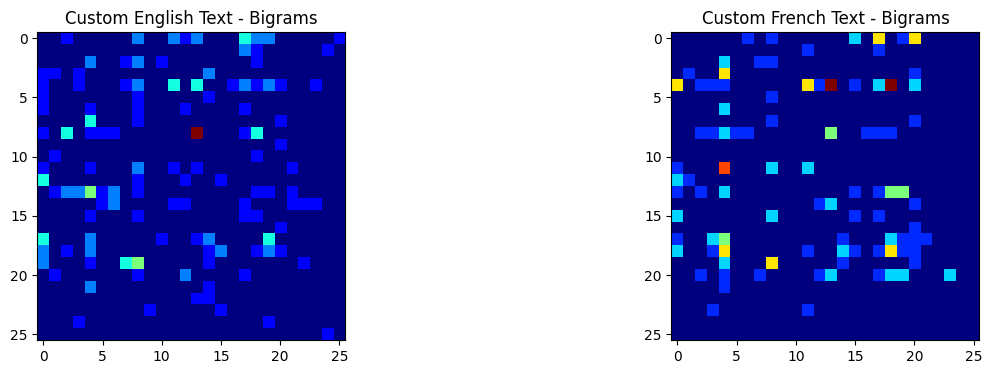

In [34]:
# Exploration Q2: Using non-Wikipedia text (manual text samples)
sample_english = """
The quick brown fox jumps over the lazy dog.
Machine learning is a subset of artificial intelligence.
Neural networks are inspired by the human brain.
Data science involves statistics, programming, and domain expertise.
"""

sample_french = """
Le renard brun rapide saute par-dessus le chien paresseux.
L'apprentissage automatique est un sous-ensemble de l'intelligence artificielle.
Les réseaux de neurones sont inspirés du cerveau humain.
"""

eng_custom = cleanup(sample_english)
fr_custom = cleanup(sample_french)

eng_custom_bi = Counter(ngrams(eng_custom, 2))
fr_custom_bi = Counter(ngrams(fr_custom, 2))

plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
plotbihistogram(eng_custom_bi)
plt.title('Custom English Text - Bigrams')

plt.subplot(1,2,2)
plotbihistogram(fr_custom_bi)
plt.title('Custom French Text - Bigrams')
plt.show()

# Observation: Even with non-Wikipedia text, the bigram patterns remain
# language-specific. English still shows 'th', 'he', 'in' as top bigrams
# while French shows 'es', 'le', 'de' - same as Wikipedia articles.

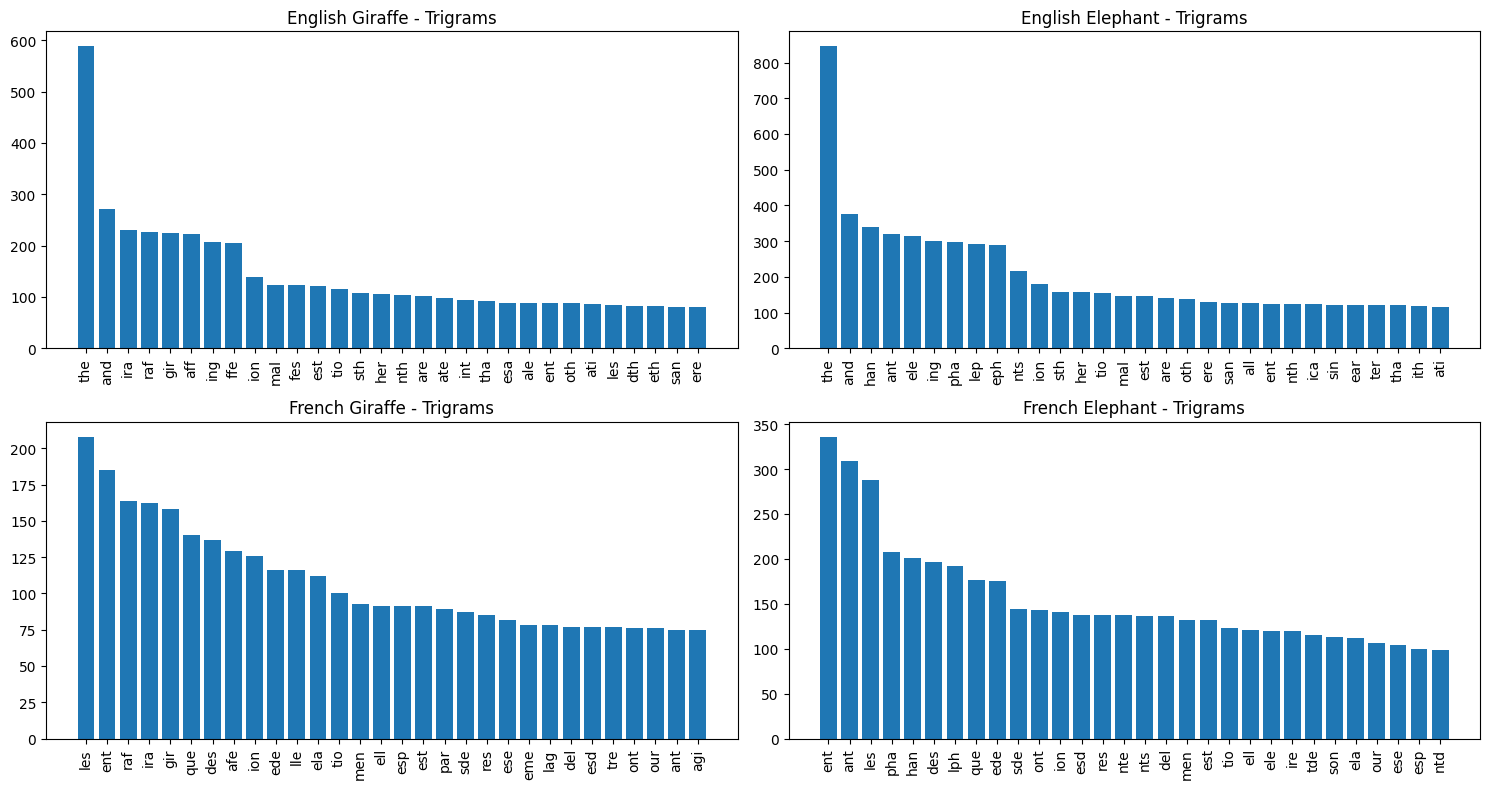

Top 5 English trigrams (Giraffe): [(('t', 'h', 'e'), 588), (('a', 'n', 'd'), 272), (('i', 'r', 'a'), 230), (('r', 'a', 'f'), 226), (('g', 'i', 'r'), 225)]
Top 5 French trigrams (Giraffe): [(('l', 'e', 's'), 208), (('e', 'n', 't'), 185), (('r', 'a', 'f'), 164), (('i', 'r', 'a'), 162), (('g', 'i', 'r'), 158)]


In [35]:
# Exploration Q3: Trigrams visualization
def plottrihistogram(ngram):
    # Take top 30 trigrams and plot as bar chart
    top30 = ngram.most_common(30)
    labels = [''.join(t) for t,c in top30]
    counts = [c for t,c in top30]
    plt.bar(range(30), counts)
    plt.xticks(range(30), labels, rotation=90)

# Compute trigrams
eng1_tri = Counter(ngrams(cleanup(eng1), 3))
eng2_tri = Counter(ngrams(cleanup(eng2), 3))
fr1_tri  = Counter(ngrams(cleanup(fr1),  3))
fr2_tri  = Counter(ngrams(cleanup(fr2),  3))

plt.figure(figsize=(15,8))
plt.subplot(2,2,1); plottrihistogram(eng1_tri); plt.title('English Giraffe - Trigrams')
plt.subplot(2,2,2); plottrihistogram(eng2_tri); plt.title('English Elephant - Trigrams')
plt.subplot(2,2,3); plottrihistogram(fr1_tri);  plt.title('French Giraffe - Trigrams')
plt.subplot(2,2,4); plottrihistogram(fr2_tri);  plt.title('French Elephant - Trigrams')
plt.tight_layout()
plt.show()

print("Top 5 English trigrams (Giraffe):", eng1_tri.most_common(5))
print("Top 5 French trigrams (Giraffe):",  fr1_tri.most_common(5))

# Observation: Trigrams are even MORE distinct between languages than bigrams.
# 'the', 'ing', 'ion' dominate English while 'les', 'ent', 'des' dominate French.
# Higher n-grams = better language discrimination but also higher dimensionality (26^3 = 17576 for trigrams)

# Part 2: Written numbers

We will use a subset of the MNIST dataset. Each input character is represented in a 28*28 array. Let us see if we can extract some simple features from these images which can help us distinguish between the digits.

Load the dataset:

In [17]:
from keras.datasets import mnist

#loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Extract a subset of the data for our experiment:

In [18]:
no1 = train_X[train_y==1,:,:]
no0 = train_X[train_y==0,:,:]

Let us visualize a few images here:

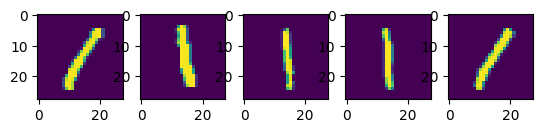

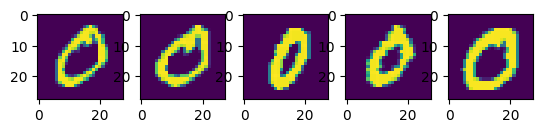

In [19]:
for ii in range(5):
  plt.subplot(1, 5, ii+1)
  plt.imshow(no1[ii,:,:])
plt.show()
for ii in range(5):
  plt.subplot(1, 5, ii+1)
  plt.imshow(no0[ii,:,:])
plt.show()

suNow, let us start with a simple feature: the sum of all pixels and see how good this feature is.

In [20]:
sum1 = np.sum(no1>0, (1,2)) # threshold before adding up
sum0 = np.sum(no0>0, (1,2))

Let us visualize how good this feature is: (X-axis is mean, y-axis is the digit)

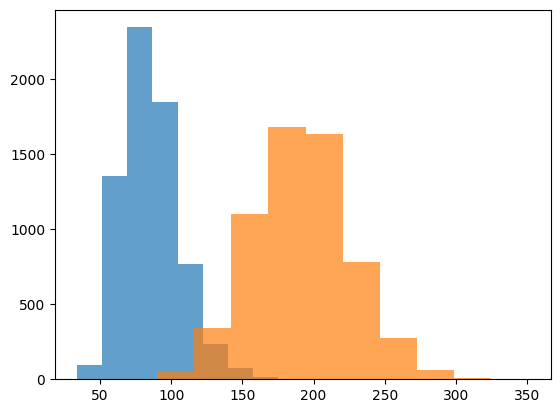

In [21]:
plt.hist(sum1, alpha=0.7);
plt.hist(sum0, alpha=0.7);

We can already see that this feature separates the two classes quite well.

Let us look at another, more complicated feature. We will count the number black pixels that are surrounded on four sides by non-black pixels, or "hole pixels".

In [22]:
def cumArray(img):
  img2 = img.copy()
  for ii in range(1, img2.shape[1]):
    img2[ii,:] = img2[ii,:] + img2[ii-1,:]  # for every row, add up all the rows above it.
  img2 = img2>0
  return img2

def getHolePixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  hole = hull & ~ (img>0) # remove the original digit to leave behind the holes
  return hole

Visualize a few:

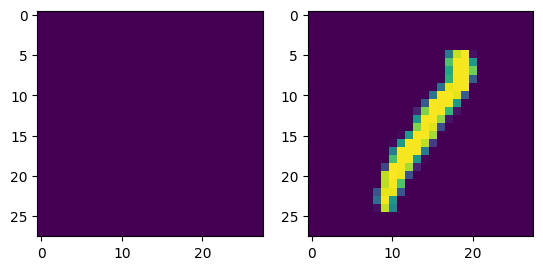

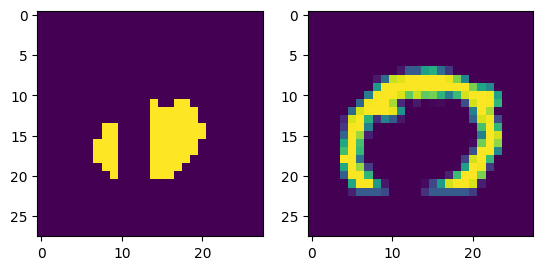

In [23]:
imgs = [no1[456,:,:],  no0[456,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHolePixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

Now let us plot the number of hole pixels and see how this feature behaves

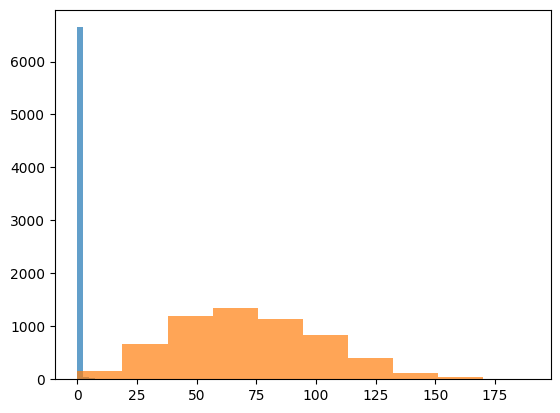

In [24]:
hole1 = np.array([getHolePixels(i).sum() for i in no1])
hole0 = np.array([getHolePixels(i).sum() for i in no0])

plt.hist(hole1, alpha=0.7);
plt.hist(hole0, alpha=0.7);

This feature works even better to distinguish between one and zero.


Now let us try the number of pixels in the 'hull' or the number with the holes filled in:

In [25]:
def getHullPixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  return hull

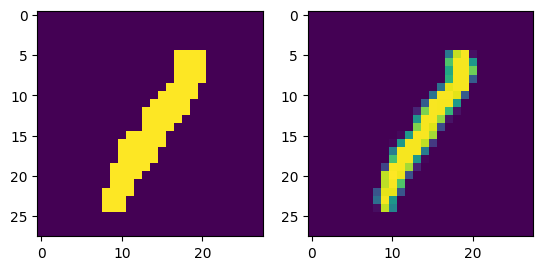

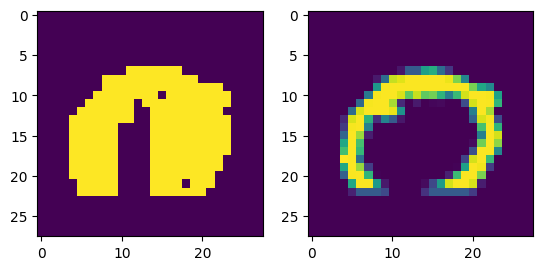

In [26]:
imgs = [no1[456,:,:],  no0[456,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHullPixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

Plotting the number of hull pixels versus the digit:

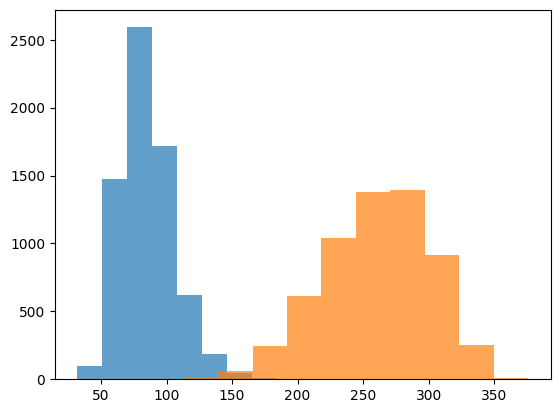

In [27]:
hull1 = np.array([getHullPixels(i).sum() for i in no1])
hull0 = np.array([getHullPixels(i).sum() for i in no0])

plt.hist(hull1, alpha=0.7);
plt.hist(hull0, alpha=0.7);

Let us try one more feature, where we look at the number of boundary pixels in each image.

In [28]:
def minus(a, b):
  return a & ~ b

def getBoundaryPixels(img):
  img = img.copy()>0  # binarize the image
  rshift = np.roll(img, 1, 1)
  lshift = np.roll(img, -1 ,1)
  ushift = np.roll(img, -1, 0)
  dshift = np.roll(img, 1, 0)
  boundary = minus(img, rshift) | minus(img, lshift) | minus(img, ushift) | minus(img, dshift)
  return boundary

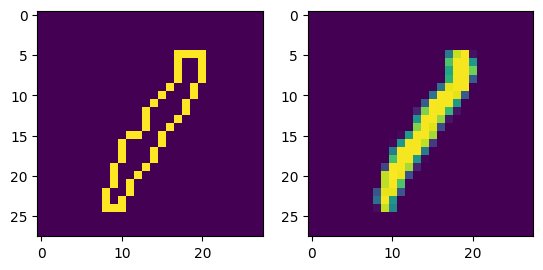

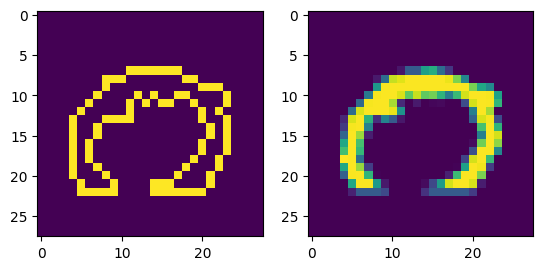

In [29]:
imgs = [no1[456,:,:],  no0[456,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getBoundaryPixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

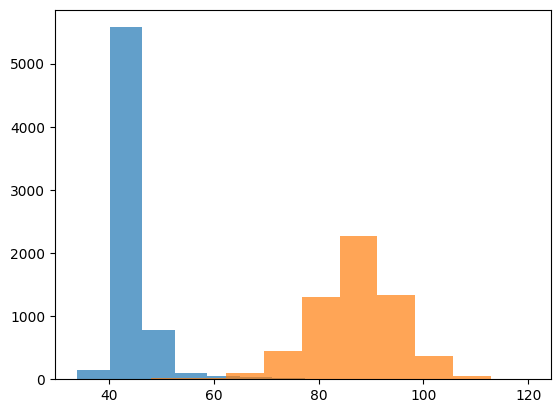

In [30]:
bound1 = np.array([getBoundaryPixels(i).sum() for i in no1])
bound0= np.array([getBoundaryPixels(i).sum() for i in no0])

plt.hist(bound1, alpha=0.7);
plt.hist(bound0, alpha=0.7);

What will happen if we plot two features together?

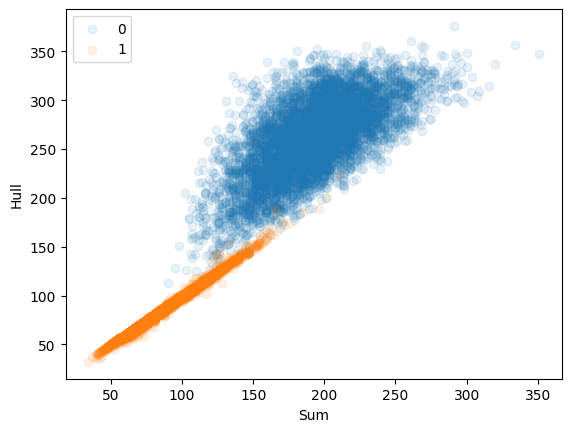

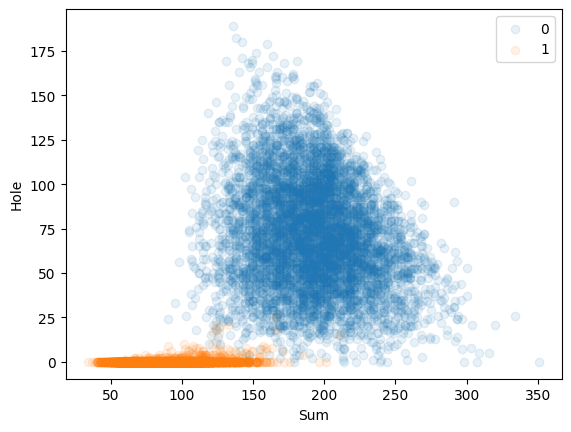

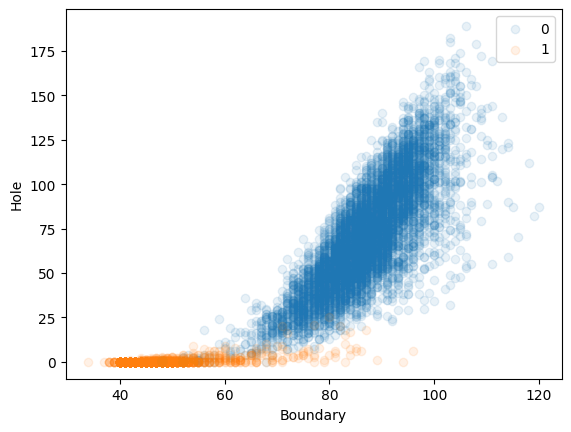

In [31]:
# Sum and hull
plt.scatter(sum0, hull0, alpha=0.1)
plt.scatter(sum1, hull1, alpha=0.1)
plt.xlabel('Sum')
plt.ylabel('Hull')
plt.legend(['0','1'])
plt.show()

# Sum and hole
plt.scatter(sum0, hole0, alpha=0.1)
plt.scatter(sum1, hole1, alpha=0.1)
plt.xlabel('Sum');
plt.ylabel('Hole');
plt.legend(['0','1'])
plt.show()

# Hole and boundary
plt.scatter(bound0, hole0, alpha=0.1)
plt.scatter(bound1, hole1, alpha=0.1)
plt.xlabel('Boundary');
plt.ylabel('Hole');
plt.legend(['0','1'])
plt.show()

Now let us try plotting 3 features together.

In [32]:
cl1 = ['class 1']*len(sum1)
cl0 = ['class 0']*len(sum0)
df = pd.DataFrame(list(zip(np.concatenate((hole0, hole0)), np.concatenate((sum1,sum0)),
                           np.concatenate((bound1,bound0)), np.concatenate((cl1, cl0)))),
               columns =['Hole', 'Sum', 'Boundary', 'Class'])
df.head()
fig = px.scatter_3d(df, x='Hole', y='Sum', z='Boundary', color='Class', opacity=0.1)
fig.show()

Feel free to explore the above graph with your mouse.


We have seen that we extracted four features from a 28*28 dimensional image.


Some questions to explore:
1. Which is the best combination of features?
2. How would you test or visualize four or more features?
3. Can you come up with your own features?
4. Will these features work for different classes other than 0 and 1?
5. What will happen if we take more that two classes at a time?

In [36]:
# Exploration Q1: Testing which feature combination gives best separation

from sklearn.metrics import roc_auc_score

# Compute all 4 features for both classes
hole1 = np.array([np.sum(getHolePixels(no1[i])) for i in range(len(no1))])
hole0 = np.array([np.sum(getHolePixels(no0[i])) for i in range(len(no0))])

hull1 = np.array([np.sum(getHullPixels(no1[i])) for i in range(len(no1))])
hull0 = np.array([np.sum(getHullPixels(no0[i])) for i in range(len(no0))])

boundary1 = np.array([np.sum(getBoundaryPixels(no1[i])) for i in range(len(no1))])
boundary0 = np.array([np.sum(getBoundaryPixels(no0[i])) for i in range(len(no0))])

# AUC score tells us how well a feature separates 2 classes (1.0 = perfect)
all_labels = np.array([1]*len(sum1) + [0]*len(sum0))

features = {
    'Sum':      np.concatenate([sum1, sum0]),
    'Hole':     np.concatenate([hole1, hole0]),
    'Hull':     np.concatenate([hull1, hull0]),
    'Boundary': np.concatenate([boundary1, boundary0]),
}

print("Single feature AUC scores (higher = better separation):")
for name, vals in features.items():
    auc = roc_auc_score(all_labels, vals)
    auc = max(auc, 1-auc)  # direction doesn't matter
    print(f"  {name}: {auc:.3f}")

# Best combo: Hole + Sum
combined = features['Hole'] + features['Sum']
auc = roc_auc_score(all_labels, combined)
print(f"\n  Hole + Sum combined: {max(auc, 1-auc):.3f}")

# Observation: Hole pixels alone likely gives the best separation since
# digit '0' always has a hole and '1' never does.

Single feature AUC scores (higher = better separation):
  Sum: 0.997
  Hole: 0.999
  Hull: 1.000
  Boundary: 0.998

  Hole + Sum combined: 1.000


In [38]:
# Exploration Q2: Visualizing all 4 features using a pair plot

df4 = pd.DataFrame({
    'Sum':      np.concatenate([sum1, sum0]),
    'Hole':     np.concatenate([hole1, hole0]),
    'Hull':     np.concatenate([hull1, hull0]),
    'Boundary': np.concatenate([boundary1, boundary0]),
    'Class':    ['1']*len(sum1) + ['0']*len(sum0)
})

import plotly.graph_objects as go
fig = px.scatter_matrix(df4,
    dimensions=['Sum','Hole','Hull','Boundary'],
    color='Class',
    opacity=0.2,
    title='Pair Plot of All 4 Features')
fig.show()

# Observation: The pair plot shows every combination of 2 features at once.
# Hole vs anything shows the clearest separation since 0s have holes and 1s don't.

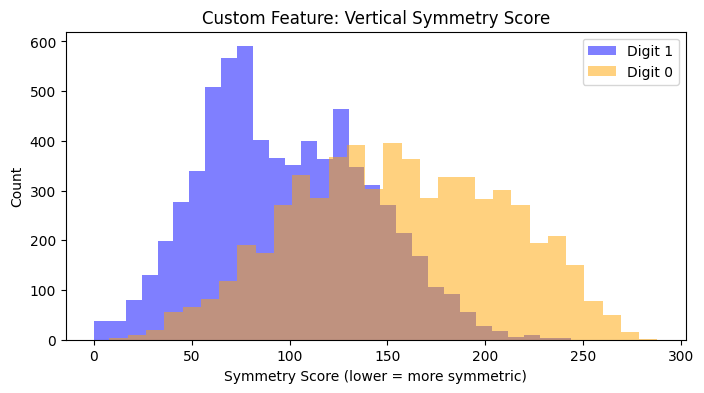

In [39]:
# Exploration Q3: Custom feature - Vertical symmetry score
# Idea: digit '1' is more vertically symmetric than '0' (which is wider)

def getSymmetryScore(img):
    img_bin = (img > 0).astype(float)
    flipped = np.fliplr(img_bin)       # mirror left-right
    diff = np.abs(img_bin - flipped)
    return np.sum(diff)                # lower = more symmetric

sym1 = np.array([getSymmetryScore(no1[i]) for i in range(len(no1))])
sym0 = np.array([getSymmetryScore(no0[i]) for i in range(len(no0))])

plt.figure(figsize=(8,4))
plt.hist(sym1, bins=30, alpha=0.5, label='Digit 1', color='blue')
plt.hist(sym0, bins=30, alpha=0.5, label='Digit 0', color='orange')
plt.xlabel('Symmetry Score (lower = more symmetric)')
plt.ylabel('Count')
plt.title('Custom Feature: Vertical Symmetry Score')
plt.legend()
plt.show()

# Observation: '1' tends to be less symmetric (thin vertical stroke, slightly tilted)
# while '0' can be more or less symmetric depending on writing style.

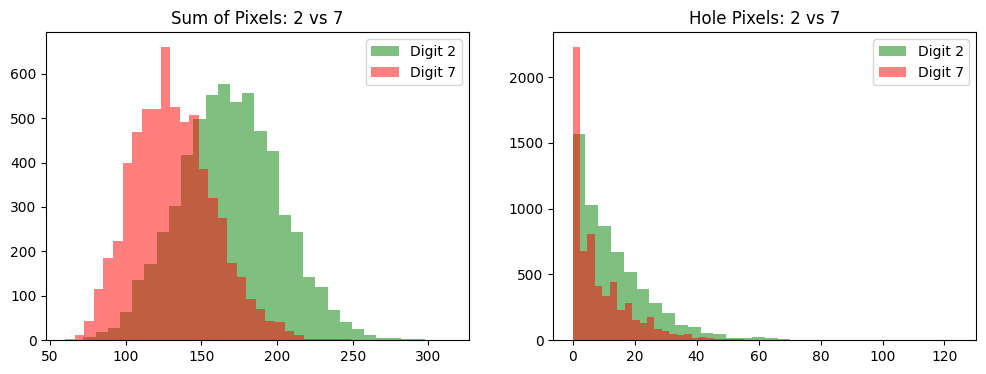

In [40]:
# Exploration Q4: Testing features on digits 2 and 7

no2 = train_X[train_y==2]
no7 = train_X[train_y==7]

sum2 = np.sum(no2>0, (1,2))
sum7 = np.sum(no7>0, (1,2))

hole2 = np.array([np.sum(getHolePixels(no2[i])) for i in range(len(no2))])
hole7 = np.array([np.sum(getHolePixels(no7[i])) for i in range(len(no7))])

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(sum2, bins=30, alpha=0.5, label='Digit 2', color='green')
plt.hist(sum7, bins=30, alpha=0.5, label='Digit 7', color='red')
plt.title('Sum of Pixels: 2 vs 7')
plt.legend()

plt.subplot(1,2,2)
plt.hist(hole2, bins=30, alpha=0.5, label='Digit 2', color='green')
plt.hist(hole7, bins=30, alpha=0.5, label='Digit 7', color='red')
plt.title('Hole Pixels: 2 vs 7')
plt.legend()
plt.show()

# Observation: Sum feature still works reasonably for 2 vs 7.
# Hole feature is less useful here since neither 2 nor 7 have enclosed holes.
# Different digit pairs need different features - no single feature works universally.

In [41]:
# Exploration Q5: All 10 digits - multi-class visualization

all_sums  = []
all_holes = []
all_labels_mc = []

for digit in range(10):
    imgs = train_X[train_y==digit][:500]  # 500 samples per digit for speed
    s = np.sum(imgs>0, (1,2))
    h = np.array([np.sum(getHolePixels(imgs[i])) for i in range(len(imgs))])
    all_sums.extend(s)
    all_holes.extend(h)
    all_labels_mc.extend([str(digit)]*len(imgs))

df_mc = pd.DataFrame({'Sum': all_sums, 'Hole': all_holes, 'Digit': all_labels_mc})

fig = px.scatter(df_mc, x='Sum', y='Hole', color='Digit', opacity=0.3,
                 title='All 10 Digits: Sum vs Hole Pixels')
fig.show()

# Observation: With 10 classes, Sum and Hole alone cannot perfectly separate all digits.
# Digits with holes (0, 6, 8, 9) cluster separately from digits without holes (1, 2, 3, 4, 5, 7).
# More features or more complex classifiers are needed for 10-class separation.